In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob


# First-year monthly online error visualization

In this notebook, we evaluate the online monthly RMSE of temperature, moisture, zonal wind, and tota cloud, and also the monthly mean evolution of near-surface temperature, precipitable water, and total cloud path. We provide the exactly code to reproduce the Figure 5 in the main text and Figure S1 in "Stable Machine-Learning Parameterization of Subgrid Processes with Real Geography and Full-physics Emulation", Hu et al. 2024, arXiv preprint:2306.08754.

## Set data path

All the simulation output, saved model weights, and preprocessed data used in Hu et al. 2024 "Stable Machine-Learning Parameterization of Subgrid Processes with Real Geography and Full-physics Emulation" are provided at zenodo (https://zenodo.org/records/12797810) that you can download. Please change the following path to your path that contains all downloaded folders.

In [2]:
data_path = '/global/homes/z/zeyuanhu/scratch/hu_etal2024_data_v2/'

In [3]:
# open the one-year reference mmf simulation
ds_sp = xr.open_dataset(data_path + 'data/h0/1year/mmf_ref/mmf_ref.eam.h0.0003.nc')

In [4]:
ps_sp = ds_sp.PS
p_interface = ds_sp.hyai*ds_sp.P0 + ds_sp.hybi*ds_sp.PS
p_interface = p_interface.values
p_interface = np.transpose(p_interface, (1,0,2))
dp = p_interface[:,1:61,:] - p_interface[:,0:60,:]
area = ds_sp.area
area_weight = area.values[np.newaxis,np.newaxis,:]
total_weight = dp*area_weight
total_weight.shape

# Function to calculate RMSE per month for total cloud mixing ratio (liquid + ice)
def calculate_rmse_qn(ds1, ds2, total_weight):
    # Determine the number of months in ds1
    num_months = ds1['CLDLIQ'].shape[0]
    
    # Slice total_weight to match the number of months in ds1
    total_weight_sliced = total_weight[:num_months, :, :]
    
    # Initialize the RMSE array with NaN values
    rmse_per_month = np.full(12, np.nan)
    
    # Compute RMSE for existing months
    squared_diff = (ds1['CLDLIQ'] - ds2['CLDLIQ'] + ds1['CLDICE'] - ds2['CLDICE']) ** 2
    weighted_squared_diff = squared_diff * total_weight_sliced
    weighted_sum = weighted_squared_diff.sum(axis=(1, 2))
    total_weight_sum = total_weight_sliced.sum(axis=(1, 2))
    weighted_mean_squared_diff = weighted_sum / total_weight_sum
    rmse_existing_months = np.sqrt(weighted_mean_squared_diff)
    
    # Fill in the RMSE array with the computed values
    rmse_per_month[:num_months] = rmse_existing_months.values
    
    return rmse_per_month

# Function to calculate RMSE per month for other variables (T, Q, U)
def calculate_rmse(ds1, ds2, total_weight,var='T'):
    # Determine the number of months in ds1
    num_months = ds1[var].shape[0]
    
    # Slice total_weight to match the number of months in ds1
    total_weight_sliced = total_weight[:num_months, :, :]
    
    # Initialize the RMSE array with NaN values
    rmse_per_month = np.full(12, np.nan)
    
    # Compute RMSE for existing months
    squared_diff = (ds1[var] - ds2[var]) ** 2
    weighted_squared_diff = squared_diff * total_weight_sliced
    weighted_sum = weighted_squared_diff.sum(axis=(1, 2))
    total_weight_sum = total_weight_sliced.sum(axis=(1, 2))
    weighted_mean_squared_diff = weighted_sum / total_weight_sum
    rmse_existing_months = np.sqrt(weighted_mean_squared_diff)
    
    # Fill in the RMSE array with the computed values
    rmse_per_month[:num_months] = rmse_existing_months.values
    
    return rmse_per_month

In [5]:
# Load the three other mmf simulations that share the same initial condition of the reference mmf run but diverge due to random numerical round off error due to GPU calculation. 
ds_sp_re = xr.open_dataset(data_path + 'data/h0/1year/mmf_a/mmf_a.eam.h0.0003.nc')
ds_sp_re_b = xr.open_dataset(data_path + 'data/h0/1year/mmf_b/mmf_b.eam.h0.0003.nc')
ds_sp_re_c = xr.open_dataset(data_path + 'data/h0/1year/mmf_c/mmf_c.eam.h0.0003.nc')

# NN case groups
case_groups = [
    [
        'mlp_v2/huber_rop',
        'mlp_v2/huber_step',
        'mlp_v2/mae_step'
    ],
    [
        'unet_v2/huber_rop',
        'unet_v2/huber_step',
        'unet_v2/mae_step'
    ],
    [
        'unet_v4/huber_rop',
        'unet_v4/huber_step',
        'unet_v4/mae_step'
    ],
    [
        'unet_v5/huber_rop',
        'unet_v5/huber_step',
        'unet_v5/mae_step'
    ],
]


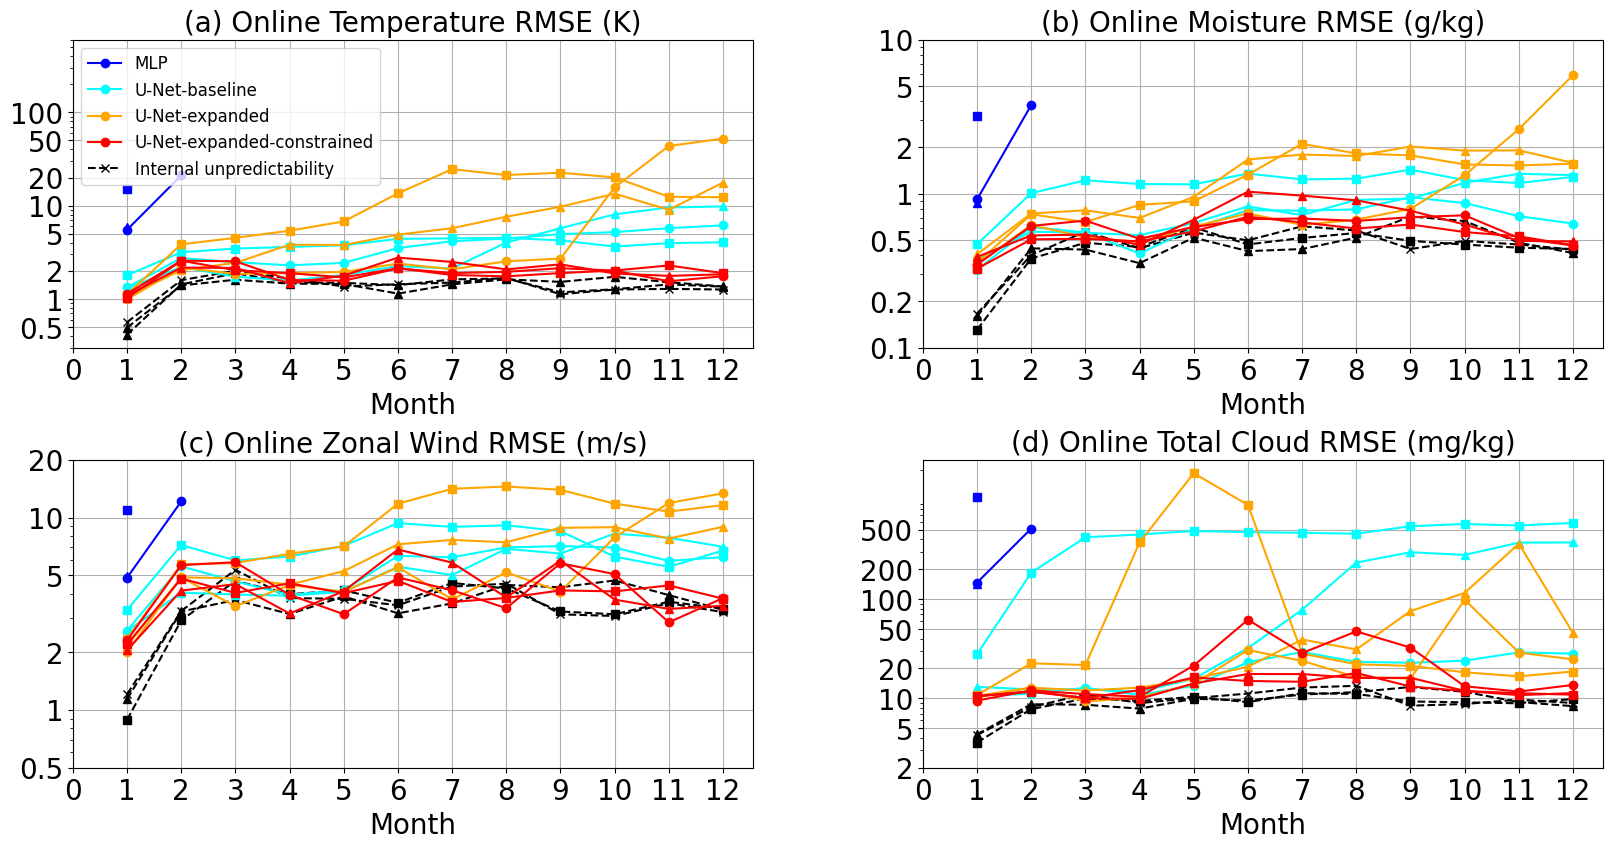

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr

# Create a figure and axes
fig, axs = plt.subplots(2, 2, figsize=(17, 14), gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [2, 1]})
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# # Adjust the upper wide panel position
# axs[0, 0].set_position([0.05, 0.75, 0.9, 0.22])
# axs[0, 1].set_visible(False)  # Hide the upper right blank plot

# Adjust the second row panels positions
axs[0, 0].set_position([0.05, 0.45, 0.4, 0.22])
axs[0, 1].set_position([0.55, 0.45, 0.4, 0.22])

# Adjust the third row panels positions
axs[1, 0].set_position([0.05, 0.15, 0.4, 0.22])
axs[1, 1].set_position([0.55, 0.15, 0.4, 0.22])


# Second row left panel (lower left)
ax = axs[0, 0]
colors = ['blue', 'cyan', 'orange', 'red']
markers = ['o', 's', '^', 'D']
var = 'T'
lines_labels = {}

rmse_per_month_sp_re = calculate_rmse(ds_sp_re, ds_sp, total_weight, var)
line, = ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='Internal unpredictability', color='black', linestyle='--', marker='x')
lines_labels['Internal unpredictability'] = line

rmse_per_month_sp_re_b = calculate_rmse(ds_sp_re_b, ds_sp, total_weight, var)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_rmse(ds_sp_re_c, ds_sp, total_weight, var)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='^')

for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        path = f'{data_path}/data/h0/1year/'
        filenames_nn = sorted(glob.glob(f'{path}{casename}/*.eam.h0.0003-*.nc'))
        ds_nn = xr.open_mfdataset(filenames_nn)
        rmse_per_month_nn = calculate_rmse(ds_nn, ds_sp, total_weight, var)
        months = np.arange(1, 13)
        label = None
        if group_idx == 0 and case_idx == 0:
            label = 'MLP'
        elif group_idx == 1 and case_idx == 0:
            label = 'U-Net-baseline'
        elif group_idx == 2 and case_idx == 0:
            label = 'U-Net-expanded'
        elif group_idx == 3 and case_idx == 0:
            label = 'U-Net-expanded-constrained'
        line, = ax.plot(months, rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])
        if label:
            lines_labels[label] = line

ax.set_yscale('log')
ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50, 100])
ax.set_yticklabels(['0.5', '1', '2', '5', '10', '20', '50', '100'], fontsize=20)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(a) Online Temperature RMSE (K)', fontsize=20)
desired_order = ['MLP', 'U-Net-baseline','U-Net-expanded', 'U-Net-expanded-constrained', 'Internal unpredictability']
# desired_order = ['MLP', 'U-Net','U-Net + expanded inputs', 'U-Net + expanded inputs + microphysical constraints', 'Internal unpredictability']
ax.legend([lines_labels[label] for label in desired_order], desired_order, fontsize=12, loc='upper left')
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)
ax.set_ylim(0.3, 600)

# Second row right panel (lower right)
ax = axs[0, 1]
var = 'Q'
rmse_per_month_sp_re = calculate_rmse(ds_sp_re, ds_sp, total_weight, var) * 1e3
ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='Internal unpredictability', color='black', linestyle='--', marker='x')
rmse_per_month_sp_re_b = calculate_rmse(ds_sp_re_b, ds_sp, total_weight, var) * 1e3
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_rmse(ds_sp_re_c, ds_sp, total_weight, var) * 1e3
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='s')

for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        path = f'{data_path}/data/h0/1year/'
        filenames_nn = sorted(glob.glob(f'{path}{casename}/*.eam.h0.0003-*.nc'))
        ds_nn = xr.open_mfdataset(filenames_nn)
        rmse_per_month_nn = calculate_rmse(ds_nn, ds_sp, total_weight, var) * 1e3
        label = None
        if group_idx == 0 and case_idx == 0:
            label = 'MLP'
        elif group_idx == 1 and case_idx == 0:
            label = 'U-Net-baseline'
        elif group_idx == 2 and case_idx == 0:
            label = 'U-Net-expanded'
        elif group_idx == 3 and case_idx == 0:
            label = 'U-Net-expanded-constrained'
        ax.plot(np.arange(1, 13), rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])

ax.set_yscale('log')
ax.set_yticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
ax.set_yticklabels(['0.1', '0.2', '0.5', '1', '2', '5', '10'], fontsize=20)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(b) Online Moisture RMSE (g/kg)', fontsize=20)
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)

# Third row left panel (lower left)
ax = axs[1, 0]
var = 'U'
rmse_per_month_sp_re = calculate_rmse(ds_sp_re, ds_sp, total_weight, var)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='Internal unpredictability', color='black', linestyle='--', marker='x')
rmse_per_month_sp_re_b = calculate_rmse(ds_sp_re_b, ds_sp, total_weight, var)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_rmse(ds_sp_re_c, ds_sp, total_weight, var)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='s')

for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        path = f'{data_path}/data/h0/1year/'
        filenames_nn = sorted(glob.glob(f'{path}{casename}/*.eam.h0.0003-*.nc'))
        ds_nn = xr.open_mfdataset(filenames_nn)
        rmse_per_month_nn = calculate_rmse(ds_nn, ds_sp, total_weight, var)
        months = np.arange(1, 13)
        label = None
        if group_idx == 0 and case_idx == 0:
            label = 'MLP'
        elif group_idx == 1 and case_idx == 0:
            label = 'U-Net-baseline'
        elif group_idx == 2 and case_idx == 0:
            label = 'U-Net-expanded'
        elif group_idx == 3 and case_idx == 0:
            label = 'U-Net-expanded-constrained'
        ax.plot(months, rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])

ax.set_yscale('log')
ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50, 100])
ax.set_yticklabels(['0.5', '1', '2', '5', '10', '20', '50', '100'], fontsize=20)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(c) Online Zonal Wind RMSE (m/s)', fontsize=20)
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)
ax.set_ylim(0.5, 20)

# Third row right panel (lower right) total cloud
ax = axs[1, 1]
rmse_per_month_sp_re = calculate_rmse_qn(ds_sp_re, ds_sp, total_weight) * 1e6
ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='Internal unpredictability', color='black', linestyle='--', marker='x')
rmse_per_month_sp_re_b = calculate_rmse_qn(ds_sp_re_b, ds_sp, total_weight) * 1e6
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_rmse_qn(ds_sp_re_c, ds_sp, total_weight) * 1e6
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='s')

for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        path = f'{data_path}/data/h0/1year/'
        filenames_nn = sorted(glob.glob(f'{path}{casename}/*.eam.h0.0003-*.nc'))
        ds_nn = xr.open_mfdataset(filenames_nn)
        rmse_per_month_nn = calculate_rmse_qn(ds_nn, ds_sp, total_weight) * 1e6
        label = None
        if group_idx == 0 and case_idx == 0:
            label = 'MLP'
        elif group_idx == 1 and case_idx == 0:
            label = 'U-Net-baseline'
        elif group_idx == 2 and case_idx == 0:
            label = 'U-Net-expanded'
        elif group_idx == 3 and case_idx == 0:
            label = 'U-Net-expanded-constrained'
        ax.plot(np.arange(1, 13), rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])

ax.set_yscale('log')
ax.set_yticks([2, 5, 10, 20, 50, 100, 200, 500])
ax.set_yticklabels(['2', '5', '10', '20', '50', '100', '200', '500'], fontsize=20)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(d) Online Total Cloud RMSE (mg/kg)', fontsize=20)
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)
# plt.savefig('james_1year-online-rmse-4models.pdf', format='pdf', dpi=300, bbox_inches='tight')
# plt.savefig('james_1year-online-rmse-4models-newlegend.pdf', format='pdf', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()


Next, let's calculate the evolution of mean near-surface temperature, precipitable water, and total cloud condensate path.

In [7]:
ds_grid = xr.open_dataset(data_path+'data/data_grid/ne4pg2_scrip.nc')
grid_area = ds_grid['grid_area'].values
area_weight_norm = grid_area/np.sum(grid_area)

In [8]:
def calculate_mean_lev(ds, area_weight=area_weight_norm,var='T',lev=None):
    # Determine the number of months in ds1
    num_months = ds[var].shape[0]

        # Initialize the RMSE array with NaN values
    mean_per_month = np.full(12, np.nan)
    if lev:
        mean_per_month[:num_months] = np.average(ds[var][:12,lev,:].values, weights=area_weight_norm,axis=1)
    else:
        mean_per_month[:num_months] = np.average(ds[var][:12,:].values, weights=area_weight_norm,axis=1)

    return mean_per_month

In [9]:
def get_tcp_mean_1file(ds, area_weight):
    cld = ds.CLDICE + ds.CLDLIQ
    ps = ds.PS
    # if cld.shape[0]>1:
    #     p_interface = ds.hyai*ds.P0 + ds.hybi*ds.PS
    # else:
    #     p_interface = ds.hyai.expand_dims(time=1)*ds.P0.expand_dims(time=1) + ds.hybi.expand_dims(time=1)*ds.PS

    # p_interface = p_interface.values
    # dp = p_interface[:,1:61,:] - p_interface[:,0:60,:]
    p_interface = ds.hyai*ds.P0 + ds.hybi*ds.PS
    p_interface = p_interface.values
    p_interface = np.transpose(p_interface, (1,0,2))
    dp = p_interface[:,1:61,:] - p_interface[:,0:60,:]
    ggr = 9.81
    tcp = np.sum(cld*dp,axis=1)/9.81
    tcp_mean = np.average(tcp, weights=area_weight,axis=1)
    return tcp_mean

def get_tcp_mean_multifile(ds, area_weight):
    cld = ds.CLDICE + ds.CLDLIQ
    ps = ds.PS
    if cld.shape[0]>1:
        p_interface = ds.hyai*ds.P0 + ds.hybi*ds.PS
    else:
        p_interface = ds.hyai.expand_dims(time=1)*ds.P0.expand_dims(time=1) + ds.hybi.expand_dims(time=1)*ds.PS

    p_interface = p_interface.values
    dp = p_interface[:,1:61,:] - p_interface[:,0:60,:]
    # p_interface = ds.hyai*ds.P0 + ds.hybi*ds.PS
    # p_interface = p_interface.values
    # p_interface = np.transpose(p_interface, (1,0,2))
    # dp = p_interface[:,1:61,:] - p_interface[:,0:60,:]
    ggr = 9.81
    tcp = np.sum(cld*dp,axis=1)/9.81
    tcp_mean = np.average(tcp, weights=area_weight,axis=1)
    return tcp_mean

def calculate_mean_cloud_path_1file(ds, area_weight=area_weight_norm):
    # Determine the number of months in ds1
    num_months = ds[var].shape[0]

        # Initialize the RMSE array with NaN values
    mean_per_month = np.full(12, np.nan)
    mean_per_month[:num_months] = get_tcp_mean_1file(ds,area_weight_norm)

    return mean_per_month

def calculate_mean_cloud_path_multifile(ds, area_weight=area_weight_norm):
    # Determine the number of months in ds1
    num_months = ds[var].shape[0]

        # Initialize the RMSE array with NaN values
    mean_per_month = np.full(12, np.nan)
    mean_per_month[:num_months] = get_tcp_mean_multifile(ds,area_weight_norm)

    return mean_per_month

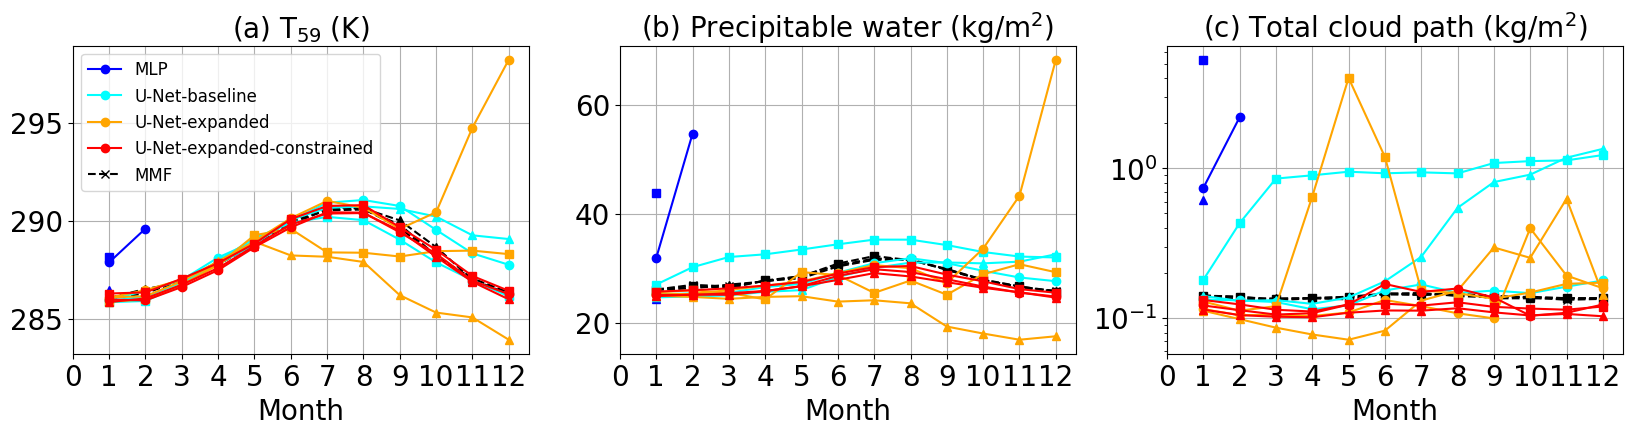

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr

# Create a figure and axes
fig, axs = plt.subplots(1, 3, figsize=(20, 4))
# fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Second row left panel (lower left)
ax = axs[0]
colors = ['blue', 'cyan', 'orange', 'red']
markers = ['o', 's', '^', 'D']
var = 'T'
lines_labels = {}

rmse_per_month_sp_re = calculate_mean_lev(ds_sp_re,var='T',lev=-1)
line, = ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='MMF', color='black', linestyle='--', marker='x')
lines_labels['MMF'] = line

rmse_per_month_sp_re_b = calculate_mean_lev(ds_sp_re_b,var='T',lev=-1)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_mean_lev(ds_sp_re_c,var='T',lev=-1)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='^')

for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        path = f'{data_path}/data/h0/1year/'
        filenames_nn = sorted(glob.glob(f'{path}{casename}/*.eam.h0.0003-*.nc'))
        ds_nn = xr.open_mfdataset(filenames_nn)
        rmse_per_month_nn = calculate_mean_lev(ds_nn,var='T',lev=-1)
        months = np.arange(1, 13)
        label = None
        if group_idx == 0 and case_idx == 0:
            label = 'MLP'
        elif group_idx == 1 and case_idx == 0:
            label = 'U-Net-baseline'
        elif group_idx == 2 and case_idx == 0:
            label = 'U-Net-expanded'
        elif group_idx == 3 and case_idx == 0:
            label = 'U-Net-expanded-constrained'
        line, = ax.plot(months, rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])
        if label:
            lines_labels[label] = line

# ax.set_yscale('log')
# ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50, 100])
# ax.set_yticklabels(['0.5', '1', '2', '5', '10', '20', '50', '100'], fontsize=20)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(a) T$_{59}$ (K)', fontsize=20)
desired_order = ['MLP', 'U-Net-baseline','U-Net-expanded', 'U-Net-expanded-constrained', 'MMF']
ax.legend([lines_labels[label] for label in desired_order], desired_order, fontsize=12, loc='upper left')
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)
ax.tick_params(axis='both', labelsize=20)
# ax.set_ylim(0.3, 600)

# Second row right panel (lower right)
ax = axs[1]
var = 'TMQ'
rmse_per_month_sp_re = calculate_mean_lev(ds_sp_re,var='TMQ')
ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='MMF', color='black', linestyle='--', marker='x')
rmse_per_month_sp_re_b = calculate_mean_lev(ds_sp_re_b,var='TMQ')
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_mean_lev(ds_sp_re_c,var='TMQ')
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='s')

for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        path = f'{data_path}/data/h0/1year/'
        filenames_nn = sorted(glob.glob(f'{path}{casename}/*.eam.h0.0003-*.nc'))
        ds_nn = xr.open_mfdataset(filenames_nn)
        rmse_per_month_nn = calculate_mean_lev(ds_nn,var='TMQ')
        label = None
        if group_idx == 0 and case_idx == 0:
            label = 'MLP'
        elif group_idx == 1 and case_idx == 0:
            label = 'U-Net-baseline'
        elif group_idx == 2 and case_idx == 0:
            label = 'U-Net-expanded'
        elif group_idx == 3 and case_idx == 0:
            label = 'U-Net-expanded-constrained'
        ax.plot(np.arange(1, 13), rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])

# ax.set_yscale('log')
# ax.set_yticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
# ax.set_yticklabels(['0.1', '0.2', '0.5', '1', '2', '5', '10'], fontsize=20)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(b) Precipitable water (kg/m$^2$)', fontsize=20)
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)
ax.tick_params(axis='both', labelsize=20)

# Third row left panel (lower left)
ax = axs[2]

rmse_per_month_sp_re = calculate_mean_cloud_path_1file(ds_sp_re)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='MMF', color='black', linestyle='--', marker='x')
rmse_per_month_sp_re_b = calculate_mean_cloud_path_1file(ds_sp_re_b)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_mean_cloud_path_1file(ds_sp_re_c)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='s')

for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        path = f'{data_path}/data/h0/1year/'
        filenames_nn = sorted(glob.glob(f'{path}{casename}/*.eam.h0.0003-*.nc'))
        ds_nn = xr.open_mfdataset(filenames_nn)
        rmse_per_month_nn = calculate_mean_cloud_path_multifile(ds_nn)
        months = np.arange(1, 13)
        label = None
        if group_idx == 0 and case_idx == 0:
            label = 'MLP'
        elif group_idx == 1 and case_idx == 0:
            label = 'U-Net-baseline'
        elif group_idx == 2 and case_idx == 0:
            label = 'U-Net-expanded'
        elif group_idx == 3 and case_idx == 0:
            label = 'U-Net-expanded-constrained'
        ax.plot(months, rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])

ax.set_yscale('log')
# ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50, 100])
# ax.set_yticklabels(['0.5', '1', '2', '5', '10', '20', '50', '100'], fontsize=20)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(c) Total cloud path (kg/m$^2$)', fontsize=20)
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)
ax.tick_params(axis='both', labelsize=20)
# ax.set_ylim(0.5, 20)

# plt.savefig('james_1year-online-mean-4models.pdf', format='pdf', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()
